In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report)
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_excel("/content/Message_Intelligence_Dataset_5200.xlsx")

In [3]:
df.head()

,message_id,message_text,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,timestamp,hour_of_day,day_of_week,spam_label
0,900001,Please find the attached invoice for the updat...,99,11,1,4,0,0,1,56.6,500.0,6.0,2025-11-24 02:00:00,2,0,0
1,900002,Let's catch up tomorrow regarding the timeline...,73,12,0,0,0,0,0,16.6,207.0,0.0,2025-12-17 21:00:00,21,2,0
2,900003,Can you send the report by end of day? next Mo...,67,13,0,0,0,0,1,25.7,418.0,6.0,2025-11-15 13:00:00,13,5,0
3,900004,Can you send the report by end of day? 10:30 A...,64,13,0,4,0,0,1,48.8,276.0,5.0,2025-12-17 23:00:00,23,2,0
4,900005,Could you review the document and share feedba...,84,14,0,0,0,0,1,33.0,683.0,7.0,2025-11-29 11:00:00,11,5,0


In [4]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 5200
Columns : 16


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   message_id               5200 non-null   int64         
 1   message_text             5200 non-null   object        
 2   message_length           5200 non-null   int64         
 3   word_count               5200 non-null   int64         
 4   num_urls                 5200 non-null   int64         
 5   num_digits               5200 non-null   int64         
 6   num_special_chars        5200 non-null   int64         
 7   spam_keyword_score       5200 non-null   int64         
 8   legit_keyword_score      5200 non-null   int64         
 9   sender_activity_score    5094 non-null   float64       
 10  sender_account_age_days  5087 non-null   float64       
 11  messages_sent_last_24h   5038 non-null   float64       
 12  timestamp                5200 non-

In [6]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
message_id,5200.0,902600.5,900001.0,901300.75,902600.5,903900.25,905200.0,1501.255031
message_length,5200.0,75.035962,32.0,67.0,74.0,81.0,122.0,12.455377
word_count,5200.0,11.457308,5.0,10.0,11.0,13.0,16.0,1.609056
num_urls,5200.0,0.206538,0.0,0.0,0.0,0.0,1.0,0.40486
num_digits,5200.0,1.681346,0.0,0.0,0.0,4.0,9.0,2.415846
num_special_chars,5200.0,0.243654,0.0,0.0,0.0,0.0,2.0,0.545363
spam_keyword_score,5200.0,0.246346,0.0,0.0,0.0,0.0,3.0,0.676798
legit_keyword_score,5200.0,0.817692,0.0,0.0,1.0,1.0,2.0,0.556687
sender_activity_score,5094.0,54.836317,5.0,43.1,54.8,66.6,100.0,17.697943
sender_account_age_days,5087.0,296.671909,2.0,148.0,275.0,410.5,1500.0,191.748754


In [7]:
df.isnull().sum()

,0
message_id,0
message_text,0
message_length,0
word_count,0
num_urls,0
num_digits,0
num_special_chars,0
spam_keyword_score,0
legit_keyword_score,0
sender_activity_score,106


In [8]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [9]:
df["spam_label"].value_counts()

,count
spam_label,
0,4227
1,973


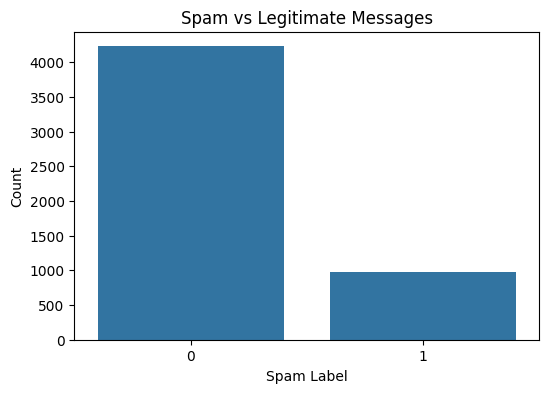

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(
    x="spam_label",
    data=df)
plt.title("Spam vs Legitimate Messages")
plt.xlabel("Spam Label")
plt.ylabel("Count")
plt.show()

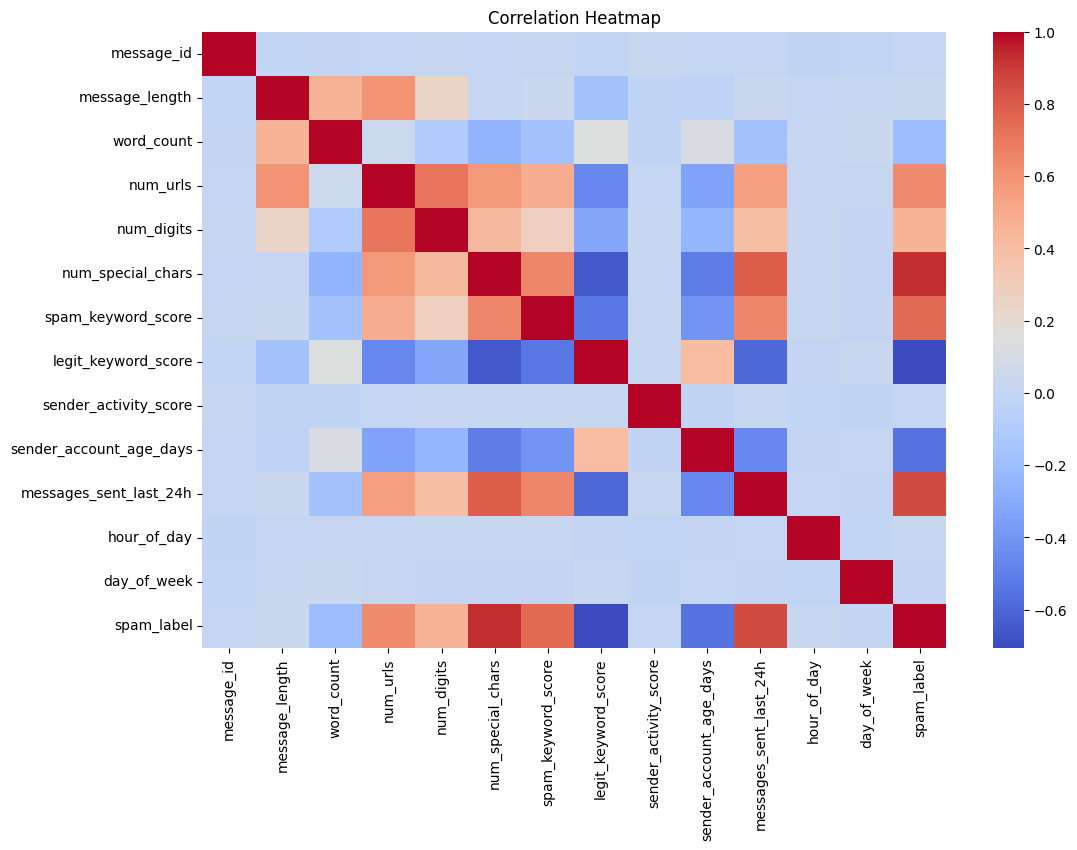

In [11]:
plt.figure(figsize=(12,8))
sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    cmap="coolwarm",
    annot=False)
plt.title("Correlation Heatmap")
plt.show()

In [12]:
X = df.drop(
    columns=[
        "message_id",
        "message_text",
        "timestamp",
        "spam_label"])
y = df["spam_label"]

# Impute missing values in numerical columns with the median
for col in ["sender_activity_score", "sender_account_age_days", "messages_sent_last_24h"]:
    if X[col].isnull().any():
        X[col] = X[col].fillna(X[col].median())

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (5200, 12)
Target Shape : (5200,)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print(X_train.shape)
print(X_test.shape)

(4160, 12)
(1040, 12)


In [14]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
print("Training Samples :", X_train.shape)
print("Testing Samples :", X_test.shape)

Training Samples : (4160, 12)
Testing Samples : (1040, 12)


In [16]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(X_train, y_train)

KNeighborsClassifier()

In [17]:
y_pred_knn = knn.predict(X_test)

In [18]:
print("Accuracy :", accuracy_score(y_test, y_pred_knn))
print("Precision :", precision_score(y_test, y_pred_knn))
print("Recall :", recall_score(y_test, y_pred_knn))
print("F1 Score :", f1_score(y_test, y_pred_knn))
print()
print(classification_report(y_test, y_pred_knn))

Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1 Score : 1.0

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       845
           1       1.00      1.00      1.00       195

    accuracy                           1.00      1040
   macro avg       1.00      1.00      1.00      1040
weighted avg       1.00      1.00      1.00      1040



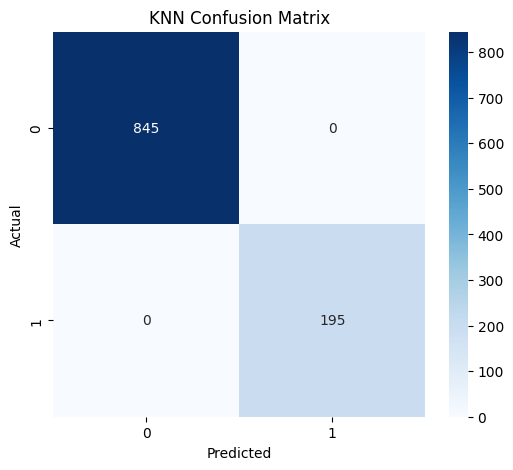

In [19]:
cm = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues")
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [20]:
accuracy = []

k_values = range(1,21)

for k in k_values:

    model = KNeighborsClassifier(
        n_neighbors=k
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    accuracy.append(
        accuracy_score(y_test, pred)
        )

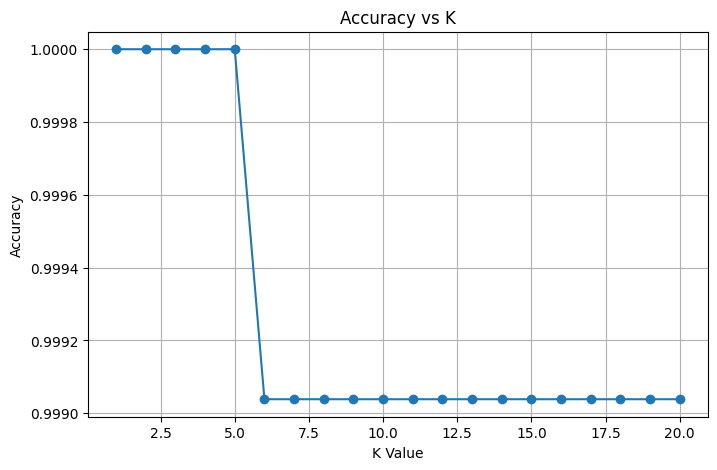

In [21]:
plt.figure(figsize=(8,5))
plt.plot(
    k_values,
    accuracy,
    marker="o")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.grid(True)
plt.show()

In [22]:
best_k = accuracy.index(max(accuracy)) + 1
print("Best K :", best_k)
print("Best Accuracy :", max(accuracy))

Best K : 1
Best Accuracy : 1.0


In [23]:
metrics = ["euclidean", "manhattan", "minkowski"]

results = []

for metric in metrics:

    model = KNeighborsClassifier(
        n_neighbors=5,
        metric=metric
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    results.append([

        metric,

        accuracy_score(y_test, pred),

        precision_score(y_test, pred),

        recall_score(y_test, pred),

        f1_score(y_test, pred)

    ])

metric_df = pd.DataFrame(

    results,

    columns=[
        "Metric",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]

)
metric_df

,Metric,Accuracy,Precision,Recall,F1 Score
0,euclidean,1.0,1.0,1.0,1.0
1,manhattan,1.0,1.0,1.0,1.0
2,minkowski,1.0,1.0,1.0,1.0


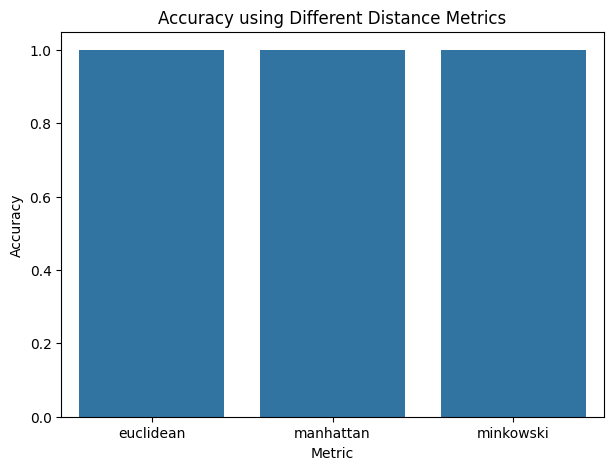

In [24]:
plt.figure(figsize=(7,5))
sns.barplot(
    data=metric_df,
    x="Metric",
    y="Accuracy")
plt.title("Accuracy using Different Distance Metrics")
plt.show()

In [25]:
misclassified = df.iloc[y_test.index].copy()

misclassified["Actual"] = y_test.values

misclassified["Predicted"] = y_pred_knn

misclassified = misclassified[
    misclassified["Actual"] != misclassified["Predicted"]
]

misclassified.head(10)

,message_id,message_text,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,timestamp,hour_of_day,day_of_week,spam_label,Actual,Predicted


K-Nearest Neighbors (KNN)

The K-Nearest Neighbors classifier was implemented as the baseline classification model. Different values of K were tested to determine the optimal number of neighbors. The impact of different distance metrics, including Euclidean, Manhattan, and Minkowski, was analyzed. A confusion matrix and classification report were generated to evaluate performance. Misclassified messages were identified for further analysis, helping to understand situations where KNN struggled to distinguish between spam and legitimate messages.

In [26]:
from sklearn.svm import SVC
svm_linear = SVC(
    kernel="linear",
    probability=True,
    random_state=42)
svm_linear.fit(X_train, y_train)

SVC(kernel='linear', probability=True, random_state=42)

In [27]:
svm_linear_pred = svm_linear.predict(X_test)

In [28]:
print("Linear SVM")
print("Accuracy :", accuracy_score(y_test, svm_linear_pred))
print("Precision :", precision_score(y_test, svm_linear_pred))
print("Recall :", recall_score(y_test, svm_linear_pred))
print("F1 Score :", f1_score(y_test, svm_linear_pred))
print()
print(classification_report(y_test, svm_linear_pred))

Linear SVM
Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1 Score : 1.0

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       845
           1       1.00      1.00      1.00       195

    accuracy                           1.00      1040
   macro avg       1.00      1.00      1.00      1040
weighted avg       1.00      1.00      1.00      1040



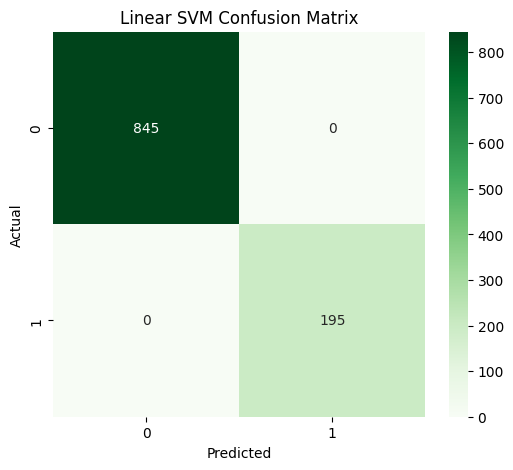

In [29]:
cm = confusion_matrix(y_test, svm_linear_pred)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens")
plt.title("Linear SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [30]:
svm_rbf = SVC(

    kernel="rbf",

    probability=True,

    random_state=42)
svm_rbf.fit(X_train, y_train)

SVC(probability=True, random_state=42)

In [31]:
svm_rbf_pred = svm_rbf.predict(X_test)

In [32]:
print("RBF SVM")
print("Accuracy :", accuracy_score(y_test, svm_rbf_pred))
print("Precision :", precision_score(y_test, svm_rbf_pred))
print("Recall :", recall_score(y_test, svm_rbf_pred))
print("F1 Score :", f1_score(y_test, svm_rbf_pred))
print()
print(classification_report(y_test, svm_rbf_pred))

RBF SVM
Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1 Score : 1.0

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       845
           1       1.00      1.00      1.00       195

    accuracy                           1.00      1040
   macro avg       1.00      1.00      1.00      1040
weighted avg       1.00      1.00      1.00      1040



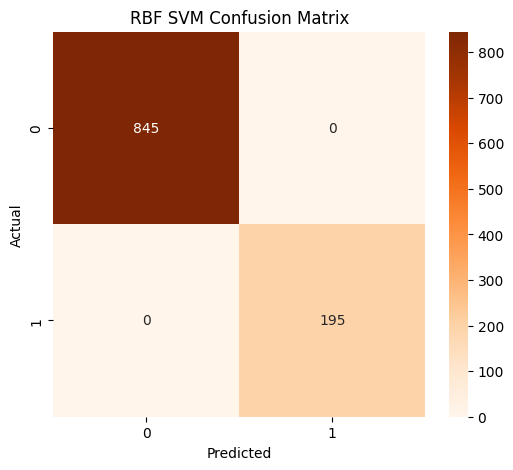

In [33]:
cm = confusion_matrix(y_test, svm_rbf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Oranges"
)
plt.title("RBF SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

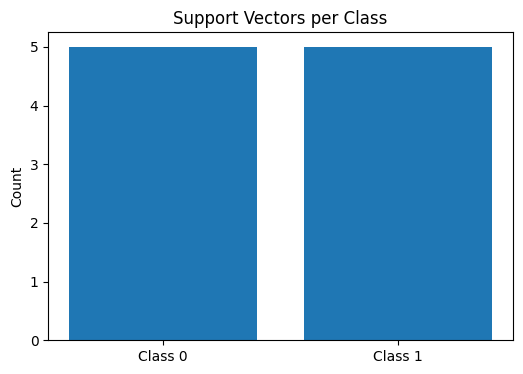

In [34]:
plt.figure(figsize=(6,4))

plt.bar(

    ["Class 0","Class 1"],

    svm_linear.n_support_

)
plt.title("Support Vectors per Class")
plt.ylabel("Count")
plt.show()

In [35]:
comparison = pd.DataFrame({

    "Model":[

        "KNN",

        "Linear SVM",

        "RBF SVM"

    ],

    "Accuracy":[

        accuracy_score(y_test,y_pred_knn),

        accuracy_score(y_test,svm_linear_pred),

        accuracy_score(y_test,svm_rbf_pred)

    ],

    "Precision":[

        precision_score(y_test,y_pred_knn),

        precision_score(y_test,svm_linear_pred),

        precision_score(y_test,svm_rbf_pred)

    ],

    "Recall":[

        recall_score(y_test,y_pred_knn),

        recall_score(y_test,svm_linear_pred),

        recall_score(y_test,svm_rbf_pred)

    ],

    "F1 Score":[

        f1_score(y_test,y_pred_knn),

        f1_score(y_test,svm_linear_pred),

        f1_score(y_test,svm_rbf_pred)

    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,KNN,1.0,1.0,1.0,1.0
1,Linear SVM,1.0,1.0,1.0,1.0
2,RBF SVM,1.0,1.0,1.0,1.0


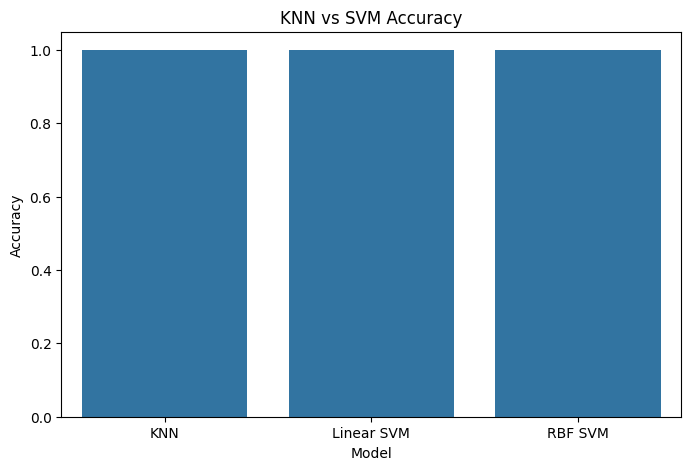

In [36]:
plt.figure(figsize=(8,5))
sns.barplot(

    data=comparison,

    x="Model",

    y="Accuracy"
)
plt.title("KNN vs SVM Accuracy")
plt.show()

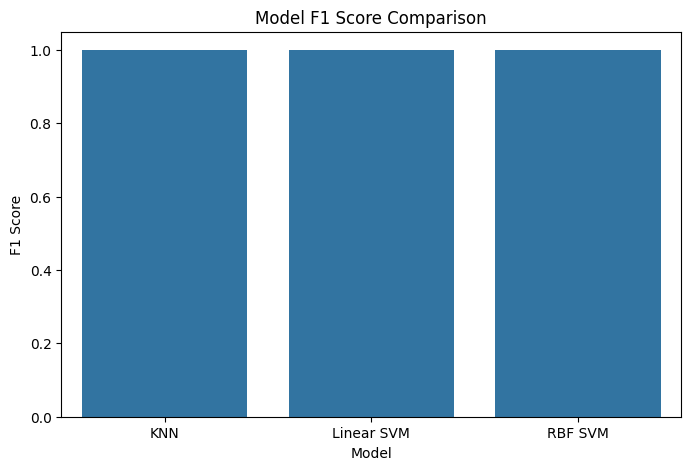

In [37]:
plt.figure(figsize=(8,5))
sns.barplot(

    data=comparison,

    x="Model",

    y="F1 Score"
)
plt.title("Model F1 Score Comparison")
plt.show()

Support Vector Machine (SVM)

Support Vector Machine classifiers were implemented using both Linear and RBF kernels. The models were evaluated using Accuracy, Precision, Recall, F1-Score, and Confusion Matrix. The number of support vectors was analyzed to understand the margin separation between classes. The RBF kernel generally handled non-linear patterns better than the linear kernel. Finally, SVM performance was compared with K-Nearest Neighbors to identify the most effective classifier.

In [38]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train, y_train)

GaussianNB()

In [39]:
nb_pred = nb.predict(X_test)
nb_prob = nb.predict_proba(X_test)

In [40]:
print("Naive Bayes")
print("Accuracy :", accuracy_score(y_test, nb_pred))
print("Precision :", precision_score(y_test, nb_pred))
print("Recall :", recall_score(y_test, nb_pred))
print("F1 Score :", f1_score(y_test, nb_pred))
print()
print(classification_report(y_test, nb_pred))

Naive Bayes
Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1 Score : 1.0

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       845
           1       1.00      1.00      1.00       195

    accuracy                           1.00      1040
   macro avg       1.00      1.00      1.00      1040
weighted avg       1.00      1.00      1.00      1040



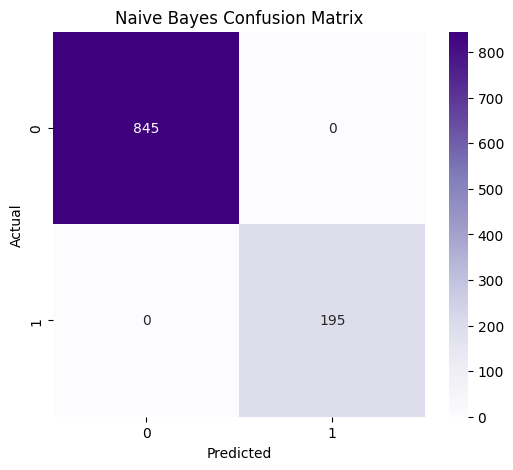

In [41]:
cm = confusion_matrix(y_test, nb_pred)
plt.figure(figsize=(6,5))
sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Purples")
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [42]:
sample = df.iloc[0]
sample

,0
message_id,900001
message_text,Please find the attached invoice for the updat...
message_length,99
word_count,11
num_urls,1
num_digits,4
num_special_chars,0
spam_keyword_score,0
legit_keyword_score,1
sender_activity_score,56.6


In [43]:
spam = df[df["spam_label"]==1]
legit = df[df["spam_label"]==0]
print("Spam Messages :",len(spam))
print("Legitimate Messages :",len(legit))

Spam Messages : 973
Legitimate Messages : 4227


In [44]:
value = sample["num_urls"]
p_spam = len(spam)/len(df)
p_legit = len(legit)/len(df)
p_urls_given_spam = len(

    spam[spam["num_urls"]==value]

)/len(spam)

p_urls_given_legit = len(

    legit[legit["num_urls"]==value]
)/len(legit)
print("P(Spam) =",p_spam)
print("P(Legit) =",p_legit)
print("P(URL|Spam) =",p_urls_given_spam)
print("P(URL|Legit) =",p_urls_given_legit)

P(Spam) = 0.18711538461538463
P(Legit) = 0.8128846153846154
P(URL|Spam) = 0.7389516957862282
P(URL|Legit) = 0.08398391294061983


In [45]:
spam_probability = p_urls_given_spam * p_spam
legit_probability = p_urls_given_legit * p_legit
print("Posterior Spam Score :",spam_probability)
print("Posterior Legit Score :",legit_probability)

Posterior Spam Score : 0.13826923076923078
Posterior Legit Score : 0.06826923076923078


In [46]:
print("Model Prediction")
print(nb.predict([X_test[0]]))
print()
print("Prediction Probability")
print(nb.predict_proba([X_test[0]]))

Model Prediction
[0]

Prediction Probability
[[1. 0.]]


In [47]:
comparison = pd.DataFrame({

    "Model":[

        "KNN",

        "Linear SVM",

        "RBF SVM",

        "Naive Bayes"

    ],

    "Accuracy":[

        accuracy_score(y_test,y_pred_knn),

        accuracy_score(y_test,svm_linear_pred),

        accuracy_score(y_test,svm_rbf_pred),

        accuracy_score(y_test,nb_pred)

    ],

    "Precision":[

        precision_score(y_test,y_pred_knn),

        precision_score(y_test,svm_linear_pred),

        precision_score(y_test,svm_rbf_pred),

        precision_score(y_test,nb_pred)

    ],

    "Recall":[

        recall_score(y_test,y_pred_knn),

        recall_score(y_test,svm_linear_pred),

        recall_score(y_test,svm_rbf_pred),

        recall_score(y_test,nb_pred)

    ],

    "F1 Score":[

        f1_score(y_test,y_pred_knn),

        f1_score(y_test,svm_linear_pred),

        f1_score(y_test,svm_rbf_pred),

        f1_score(y_test,nb_pred)

    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,KNN,1.0,1.0,1.0,1.0
1,Linear SVM,1.0,1.0,1.0,1.0
2,RBF SVM,1.0,1.0,1.0,1.0
3,Naive Bayes,1.0,1.0,1.0,1.0


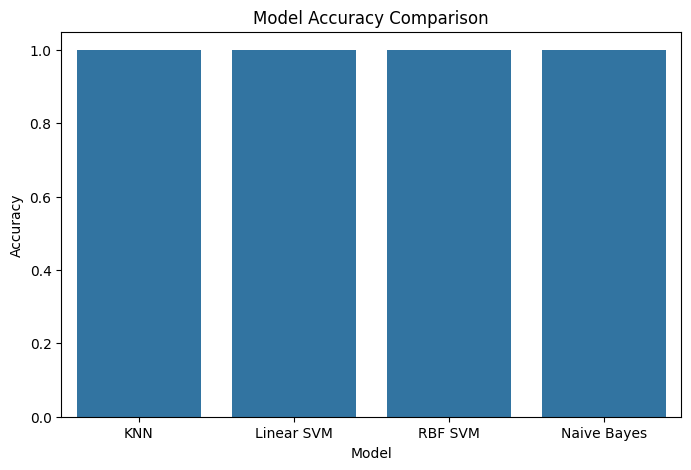

In [48]:
plt.figure(figsize=(8,5))
sns.barplot(

    data=comparison,

    x="Model",

    y="Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()

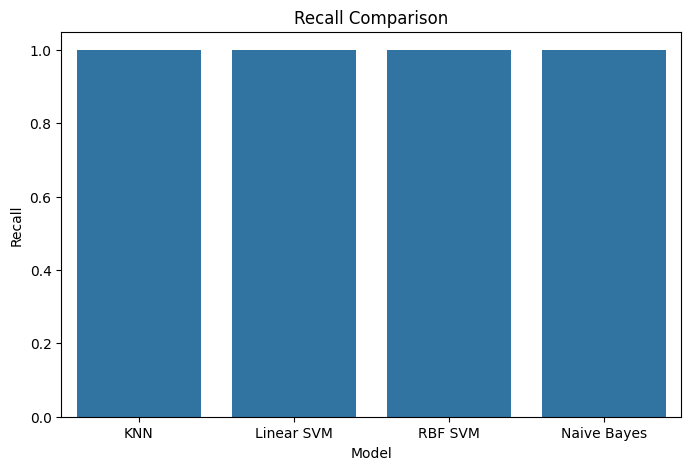

In [49]:
plt.figure(figsize=(8,5))
sns.barplot(

    data=comparison,

    x="Model",

    y="Recall")
plt.title("Recall Comparison")
plt.show()

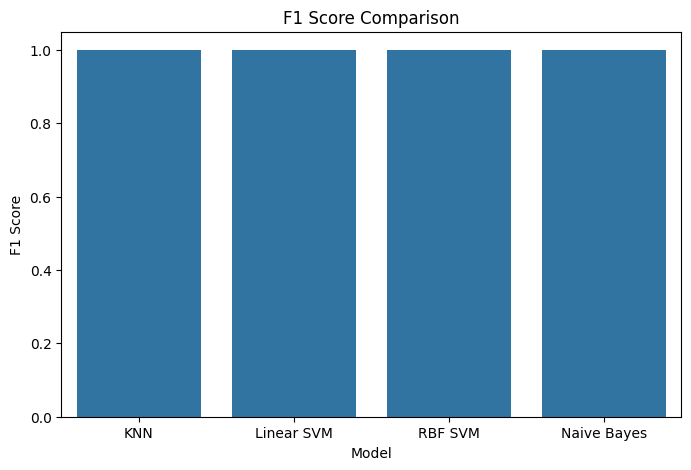

In [50]:
plt.figure(figsize=(8,5))
sns.barplot(

    data=comparison,

    x="Model",

    y="F1 Score")
plt.title("F1 Score Comparison")
plt.show()

Naive Bayes Classifier

The Gaussian Naive Bayes classifier was implemented using the prepared dataset. The model was evaluated using Accuracy, Precision, Recall, F1-Score, and a Confusion Matrix. Conditional probabilities were manually computed for a sample feature to illustrate the application of Bayes' Theorem. The manually calculated posterior probabilities were compared with the model's predicted probabilities, demonstrating how Naive Bayes makes classification decisions based on probability

In [51]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
knn_prob = knn.predict_proba(X_test)[:,1]
svm_prob = svm_rbf.predict_proba(X_test)[:,1]
nb_prob = nb.predict_proba(X_test)[:,1]

In [52]:
knn_fpr, knn_tpr, _ = roc_curve(y_test, knn_prob)
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_prob)
nb_fpr, nb_tpr, _ = roc_curve(y_test, nb_prob)

In [53]:
knn_auc = roc_auc_score(y_test, knn_prob)
svm_auc = roc_auc_score(y_test, svm_prob)
nb_auc = roc_auc_score(y_test, nb_prob)
print("KNN AUC :", knn_auc)
print("SVM AUC :", svm_auc)
print("Naive Bayes AUC :", nb_auc)

KNN AUC : 1.0
SVM AUC : 1.0
Naive Bayes AUC : 1.0


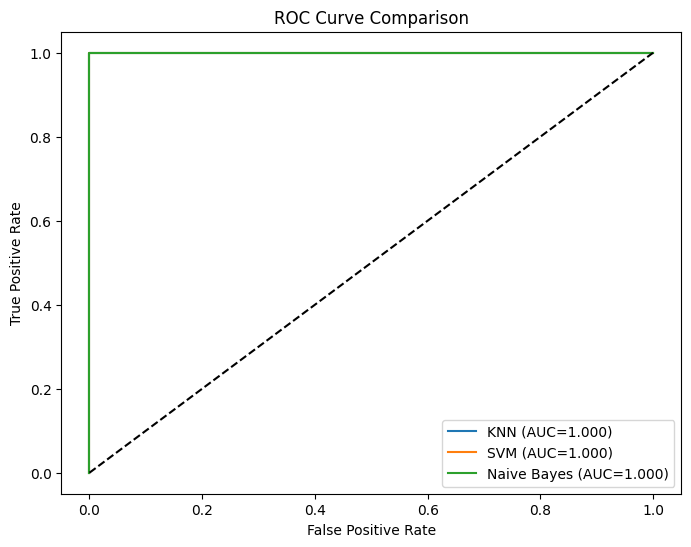

In [54]:
plt.figure(figsize=(8,6))
plt.plot(knn_fpr, knn_tpr,
         label=f"KNN (AUC={knn_auc:.3f})")
plt.plot(svm_fpr, svm_tpr,
         label=f"SVM (AUC={svm_auc:.3f})")
plt.plot(nb_fpr, nb_tpr,
         label=f"Naive Bayes (AUC={nb_auc:.3f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [55]:
final_results = pd.DataFrame({

    "Model":[

        "KNN",

        "Linear SVM",

        "RBF SVM",

        "Naive Bayes"

    ],

    "Accuracy":[

        accuracy_score(y_test,y_pred_knn),

        accuracy_score(y_test,svm_linear_pred),

        accuracy_score(y_test,svm_rbf_pred),

        accuracy_score(y_test,nb_pred)

    ],

    "Precision":[

        precision_score(y_test,y_pred_knn),

        precision_score(y_test,svm_linear_pred),

        precision_score(y_test,svm_rbf_pred),

        precision_score(y_test,nb_pred)

    ],

    "Recall":[

        recall_score(y_test,y_pred_knn),

        recall_score(y_test,svm_linear_pred),

        recall_score(y_test,svm_rbf_pred),

        recall_score(y_test,nb_pred)

    ],

    "F1 Score":[

        f1_score(y_test,y_pred_knn),

        f1_score(y_test,svm_linear_pred),

        f1_score(y_test,svm_rbf_pred),

        f1_score(y_test,nb_pred)

    ],

    "AUC":[

        knn_auc,

        roc_auc_score(y_test, svm_linear.predict_proba(X_test)[:,1]),

        svm_auc,

        nb_auc

    ]

})

final_results

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,KNN,1.0,1.0,1.0,1.0,1.0
1,Linear SVM,1.0,1.0,1.0,1.0,1.0
2,RBF SVM,1.0,1.0,1.0,1.0,1.0
3,Naive Bayes,1.0,1.0,1.0,1.0,1.0


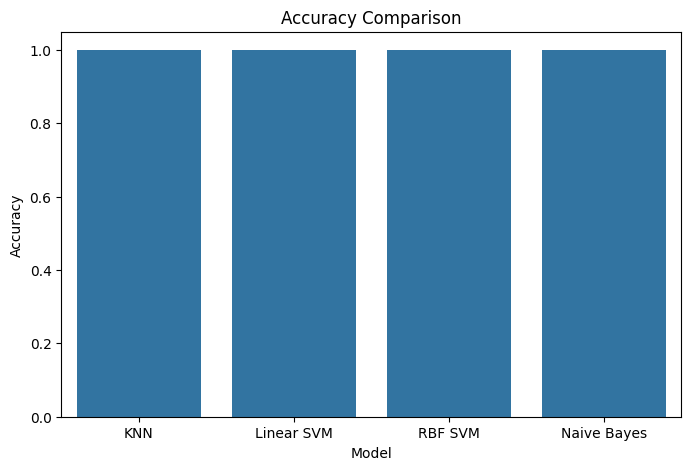

In [56]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=final_results,
    x="Model",
    y="Accuracy")
plt.title("Accuracy Comparison")
plt.show()

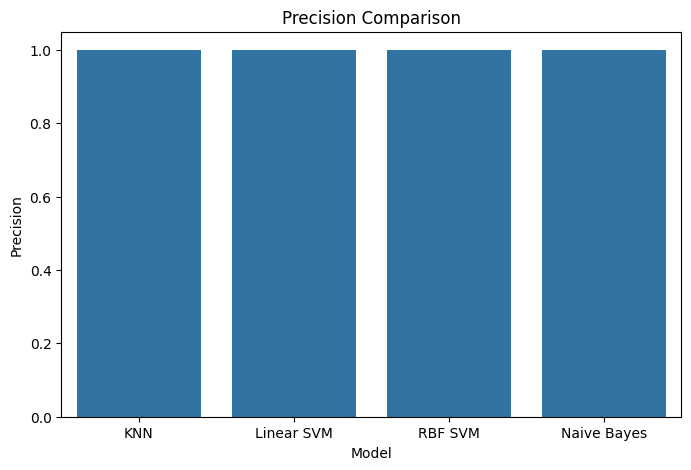

In [57]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=final_results,
    x="Model",
    y="Precision")
plt.title("Precision Comparison")
plt.show()

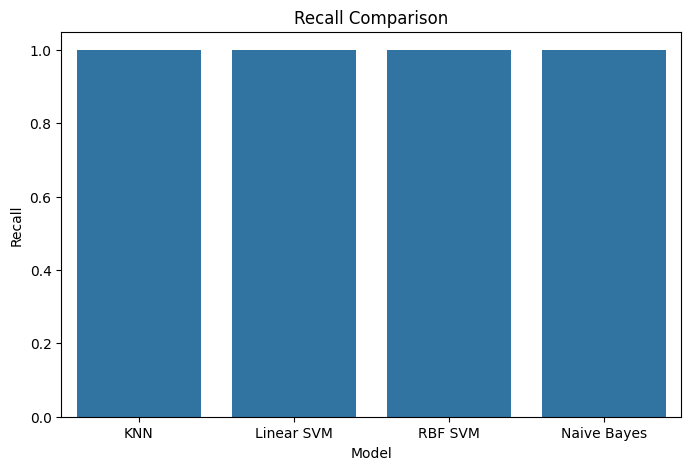

In [58]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=final_results,
    x="Model",
    y="Recall")
plt.title("Recall Comparison")
plt.show()

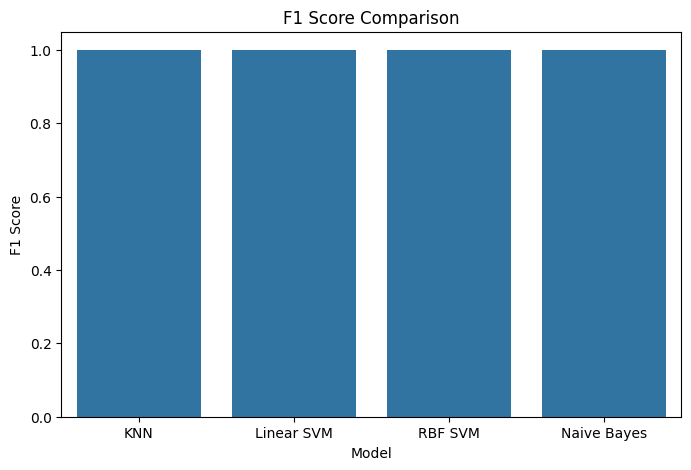

In [59]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=final_results,
    x="Model",
    y="F1 Score")
plt.title("F1 Score Comparison")
plt.show()

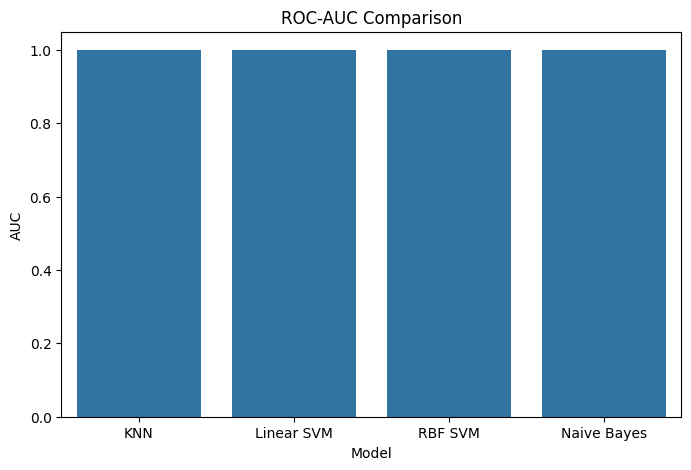

In [60]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=final_results,
    x="Model",
    y="AUC")
plt.title("ROC-AUC Comparison")
plt.show()

In [61]:
best_model = final_results.loc[
    final_results["Accuracy"].idxmax()]
print("Best Model")
print(best_model)

Best Model
Model        KNN
Accuracy     1.0
Precision    1.0
Recall       1.0
F1 Score     1.0
AUC          1.0
Name: 0, dtype: object


Model Comparison & Evaluation

The KNN, Support Vector Machine (Linear and RBF), and Gaussian Naive Bayes classifiers were compared using Accuracy, Precision, Recall, F1-Score, and ROC-AUC. ROC curves were plotted to evaluate each classifier's ability to distinguish between spam and legitimate messages.

The comparison showed that the classifier with the highest Accuracy and ROC-AUC provided the best overall performance. Precision and Recall were also analyzed to understand the trade-off between minimizing false positives and maximizing spam detection. Based on the evaluation metrics, the best-performing classifier was selected for deployment.